# Predictive Analytics: Neural Network

Note: theoretically we would need to either encode the spatial feature (i. e. community area) or train a separate model for each spatial unit. Otherwise the feature "community_area" is a continuous numeric feature!

In [1]:
import polars as pl
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from pathlib import Path
import math
import matplotlib.pyplot as plt

from run_config import MODELS_DIR, PATHS

from helper_functions import (
    get_torch_device,
    load_model_from_checkpoint,
    collect_predictions,
    compute_regression_metrics,
    plot_regression_diagnostics,
)

## Preparations

In [2]:
# Dataset loop configuration
DATASET_CONFIGS = (
    {"spatial_unit": "hexagon", "spatial_col": "h3_cell", "time_unit": "1h"},
    {"spatial_unit": "census_tracts", "spatial_col": "census_tract", "time_unit": "1h"},
    {"spatial_unit": "community_areas", "spatial_col": "community_area", "time_unit": "1h"},
    {"spatial_unit": "hexagon", "spatial_col": "h3_cell", "time_unit": "2h"},
    {"spatial_unit": "census_tracts", "spatial_col": "census_tract", "time_unit": "2h"},
    {"spatial_unit": "community_areas", "spatial_col": "community_area", "time_unit": "2h"},
    {"spatial_unit": "hexagon", "spatial_col": "h3_cell", "time_unit": "4h"},
    {"spatial_unit": "census_tracts", "spatial_col": "census_tract", "time_unit": "4h"},
    {"spatial_unit": "community_areas", "spatial_col": "community_area", "time_unit": "4h"},
)
MODEL_PATH = MODELS_DIR
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Target and feature selection
TARGET_COL = "trip_count"
EXCLUDE_COLS = [
    TARGET_COL,
    "datetime_hour",      # real timestamp would lead to much leakage
    "_split_bucket",      # only used for splitting
    "month", # cyclic feature is used instead
    "weekday", # cyclic feature is used instead
    "hour", # cyclic feature is used instead
    # all other taxi data columns must be excluded to prevent leakage
    "trip_seconds_sum",
    "trip_seconds_mean",
    "trip_seconds_min",
    "trip_seconds_max",
    "trip_miles_sum",
    "trip_miles_mean",
    "trip_miles_min",
    "trip_miles_max",
    "fare_sum",
    "fare_mean",
    "fare_min",
    "fare_max",
    "tips_sum",
    "tips_mean",
    "tips_min",
    "tips_max",
    "tolls_sum",
    "tolls_mean",
    "tolls_min",
    "tolls_max",
    "extras_sum",
    "extras_mean",
    "extras_min",
    "extras_max",
    "trip_total_sum",
    "trip_total_mean",
    "trip_total_min",
    "trip_total_max",
    "most_common_payment_type",
]

        

**BATCH_SIZE** we start with a standard batch_size of 1024 as we have a lot of training data and a smaller batch_size would lead to too many updates in each epoche

Possible, other used batch_sizes could be: 32, 64, 128, 256, 512, 1024, 2048

In [3]:
BATCH_SIZE = 1024
EPOCHS = 100
PATIENCE = 10
MIN_DELTA = 0.0


## First Baseline Model

### Model architecture
The first Baseline-Model is very simple with 2 hidden layers. Layer 1 has 64 neurons and layer 2 32. We use ReLu as activation function

In [4]:
class TaxiDemandNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

In [5]:
device = get_torch_device()
print("Using device:", device)


Using device: mps


### Trainingsloop and Validation

In [6]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    
    total_loss = 0.0
    total_samples = 0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        # 1. Alte Gradienten löschen
        optimizer.zero_grad()
        
        # 2. Forward Pass
        y_pred = model(X_batch)
        
        # 3. Loss berechnen
        loss = criterion(y_pred, y_batch)
        
        # 4. Backpropagation
        loss.backward()
        
        # 5. Gewichte updaten
        optimizer.step()
        
        batch_size = X_batch.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size
    
    avg_loss = total_loss / total_samples
    return avg_loss

def evaluate(model, val_loader, criterion, device):
    model.eval()
    
    total_loss = 0.0
    total_absolute_error = 0.0
    total_squared_error = 0.0
    total_samples = 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            
            batch_size = X_batch.size(0)
            
            total_loss += loss.item() * batch_size
            total_absolute_error += torch.sum(torch.abs(y_pred - y_batch)).item()
            total_squared_error += torch.sum((y_pred - y_batch) ** 2).item()
            total_samples += batch_size
    
    avg_loss = total_loss / total_samples
    mae = total_absolute_error / total_samples
    rmse = (total_squared_error / total_samples) ** 0.5
    
    return avg_loss, mae, rmse

### Start trainingsloop

We use checkpoint to store the models parameter after each epoche

In [7]:
def train_dataset_baseline(dataset_config):
    spatial_unit = dataset_config["spatial_unit"]
    spatial_col = dataset_config["spatial_col"]
    time_unit = dataset_config["time_unit"]
    dataset_stem = f"GOLD_{time_unit.upper()}_DEMAND_{spatial_unit.upper()}"
    model_tag = f"{spatial_unit}_{time_unit}"
    training_data_path = PATHS.train_test_dir / f"{dataset_stem}_TRAIN.parquet"
    val_data_path = PATHS.train_test_dir / f"{dataset_stem}_VAL.parquet"
    print(f"\n=== Training baseline: {model_tag} ===")
    train_df = pl.scan_parquet(training_data_path)
    val_df = pl.scan_parquet(val_data_path)
    feature_cols = [col for col in train_df.collect_schema().names() if col not in EXCLUDE_COLS]
    X_train, y_train = train_df.select(feature_cols).collect(), train_df.select(TARGET_COL).collect()
    X_val, y_val = val_df.select(feature_cols).collect(), val_df.select(TARGET_COL).collect()
    if X_train.height == 0 or X_val.height == 0:
        raise ValueError(f"Empty train or validation split for {model_tag}")

    spatial_values = sorted(X_train.select(pl.col(spatial_col).cast(pl.String)).to_series().unique().to_list())
    spatial_to_idx = {value: index for index, value in enumerate(spatial_values)}
    def encode_spatial(frame):
        return frame.with_columns(
            pl.col(spatial_col).cast(pl.String).replace_strict(spatial_to_idx, default=-1)
            .cast(pl.Float32).alias(spatial_col)
        )
    X_train, X_val = encode_spatial(X_train), encode_spatial(X_val)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train.to_numpy()).astype("float32")
    X_val_scaled = scaler.transform(X_val.to_numpy()).astype("float32")
    X_train_tensor, X_val_tensor = torch.tensor(X_train_scaled), torch.tensor(X_val_scaled)
    y_train_tensor = torch.tensor(y_train.to_numpy().astype("float32"))
    y_val_tensor = torch.tensor(y_val.to_numpy().astype("float32"))
    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=BATCH_SIZE, shuffle=False)

    input_dim = X_train_tensor.shape[1]
    model = TaxiDemandNN(input_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    history = []
    best_val_loss, epochs_without_improvement = float("inf"), 0
    best_model_path = MODEL_PATH / f"baseline_NN_{model_tag}_best_model.pt"

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_mae, val_rmse = evaluate(model, val_loader, criterion, device)
        if not math.isfinite(train_loss) or not math.isfinite(val_loss):
            print(f"Stopping {model_tag}: non-finite loss detected")
            break
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "val_mae": val_mae, "val_rmse": val_rmse})
        checkpoint = {
            **history[-1], "model_tag": model_tag, "input_dim": input_dim, "batch_size": BATCH_SIZE,
            "feature_cols": feature_cols, "spatial_to_idx": spatial_to_idx,
            "model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(),
        }
        if val_loss < best_val_loss - MIN_DELTA:
            best_val_loss, epochs_without_improvement = val_loss, 0
            torch.save(checkpoint, best_model_path)
        else:
            epochs_without_improvement += 1
        print(
            f"{model_tag} | {epoch:03d}/{EPOCHS} | train={train_loss:.4f} | val={val_loss:.4f} | "
            f"MAE={val_mae:.4f} | RMSE={val_rmse:.4f} | stale={epochs_without_improvement}/{PATIENCE}"
        )
        if epochs_without_improvement >= PATIENCE:
            break

    history_df = pl.DataFrame(history)
    history_path = MODEL_PATH / f"baseline_NN_{model_tag}_training_history.parquet"
    history_df.write_parquet(history_path)
    print(f"Saved training history: {history_path}")
    checkpoint = torch.load(best_model_path, map_location=device)
    model = TaxiDemandNN(input_dim=checkpoint["input_dim"]).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    val_eval_df = collect_predictions(
        model,
        val_loader,
        device=device,
        embedding_input=False,
        inverse_target=lambda values: values,
    )
    val_metrics_df = compute_regression_metrics(val_eval_df)
    figure, bucket_eval_df = plot_regression_diagnostics(val_eval_df)
    return {
        "model_tag": model_tag, "model_path": best_model_path, "history_path": history_path,
        "history_df": history_df, "metrics": val_metrics_df, "bucket_metrics": bucket_eval_df,
    }



=== Training baseline: hexagon_1h ===
hexagon_1h | 001/100 | train=52.7965 | val=53.1614 | MAE=1.4586 | RMSE=7.2912 | stale=0/10
hexagon_1h | 002/100 | train=52.7924 | val=53.1609 | MAE=1.4770 | RMSE=7.2912 | stale=0/10
hexagon_1h | 003/100 | train=52.7927 | val=53.1609 | MAE=1.4762 | RMSE=7.2912 | stale=1/10
hexagon_1h | 004/100 | train=52.7925 | val=53.1619 | MAE=1.5041 | RMSE=7.2912 | stale=2/10
hexagon_1h | 005/100 | train=52.7926 | val=53.1612 | MAE=1.4642 | RMSE=7.2912 | stale=3/10
hexagon_1h | 006/100 | train=52.7927 | val=53.1615 | MAE=1.4574 | RMSE=7.2912 | stale=4/10
hexagon_1h | 007/100 | train=52.7926 | val=53.1610 | MAE=1.4838 | RMSE=7.2912 | stale=5/10
hexagon_1h | 008/100 | train=52.7925 | val=53.1621 | MAE=1.4472 | RMSE=7.2912 | stale=6/10
hexagon_1h | 009/100 | train=52.7925 | val=53.1610 | MAE=1.4694 | RMSE=7.2912 | stale=7/10
hexagon_1h | 010/100 | train=52.7925 | val=53.1610 | MAE=1.4740 | RMSE=7.2912 | stale=8/10
hexagon_1h | 011/100 | train=52.7925 | val=53.1610 

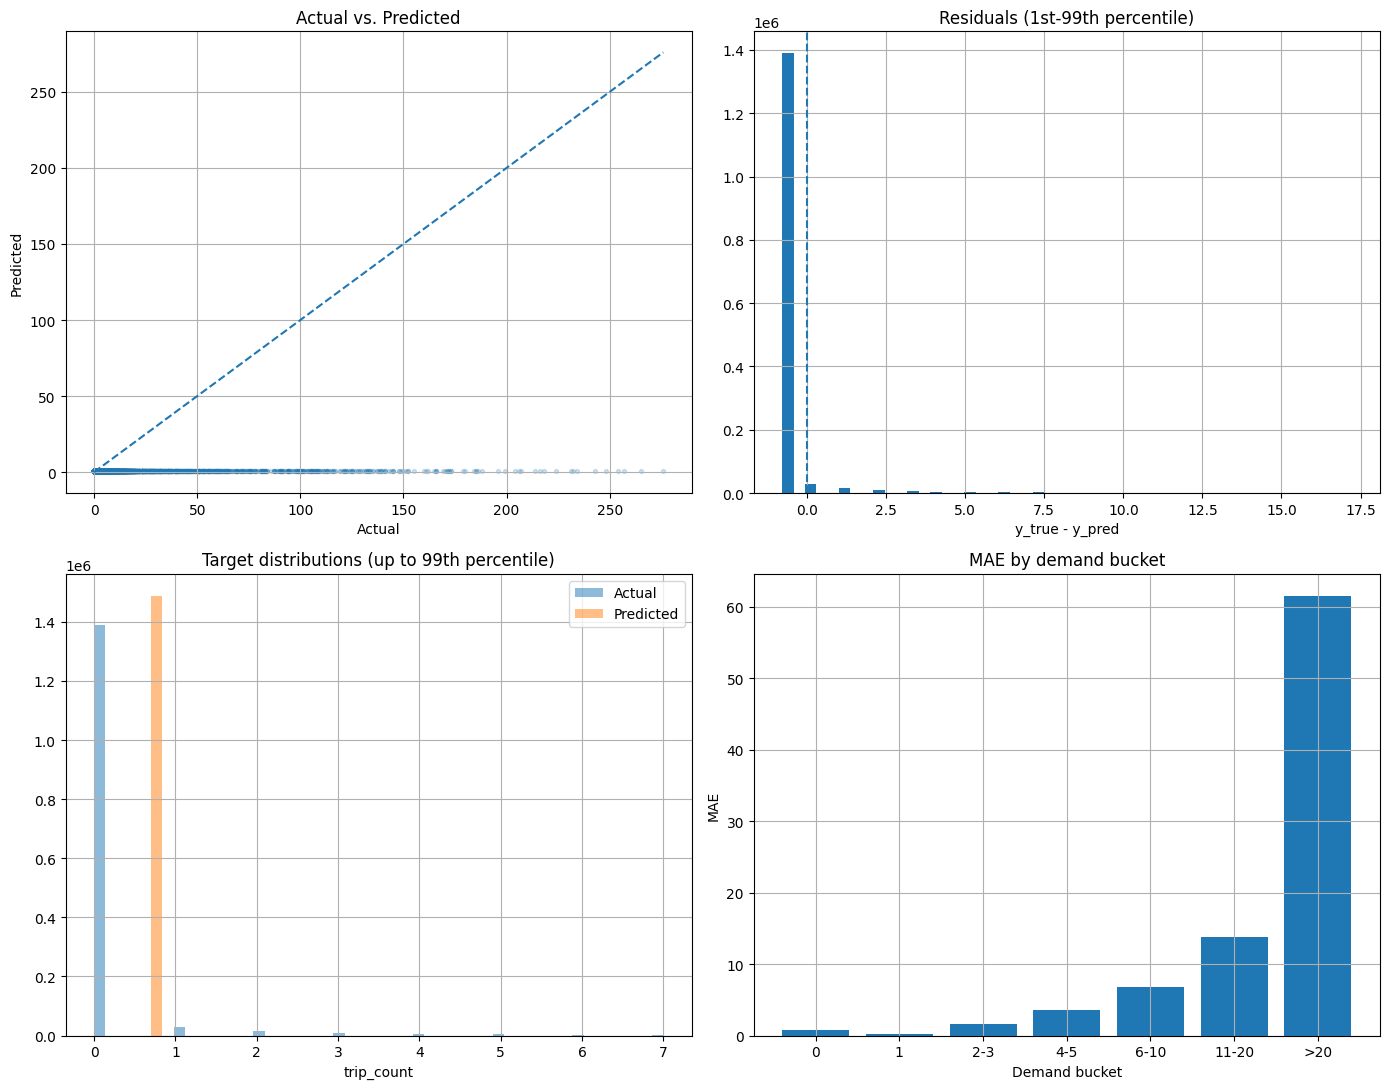

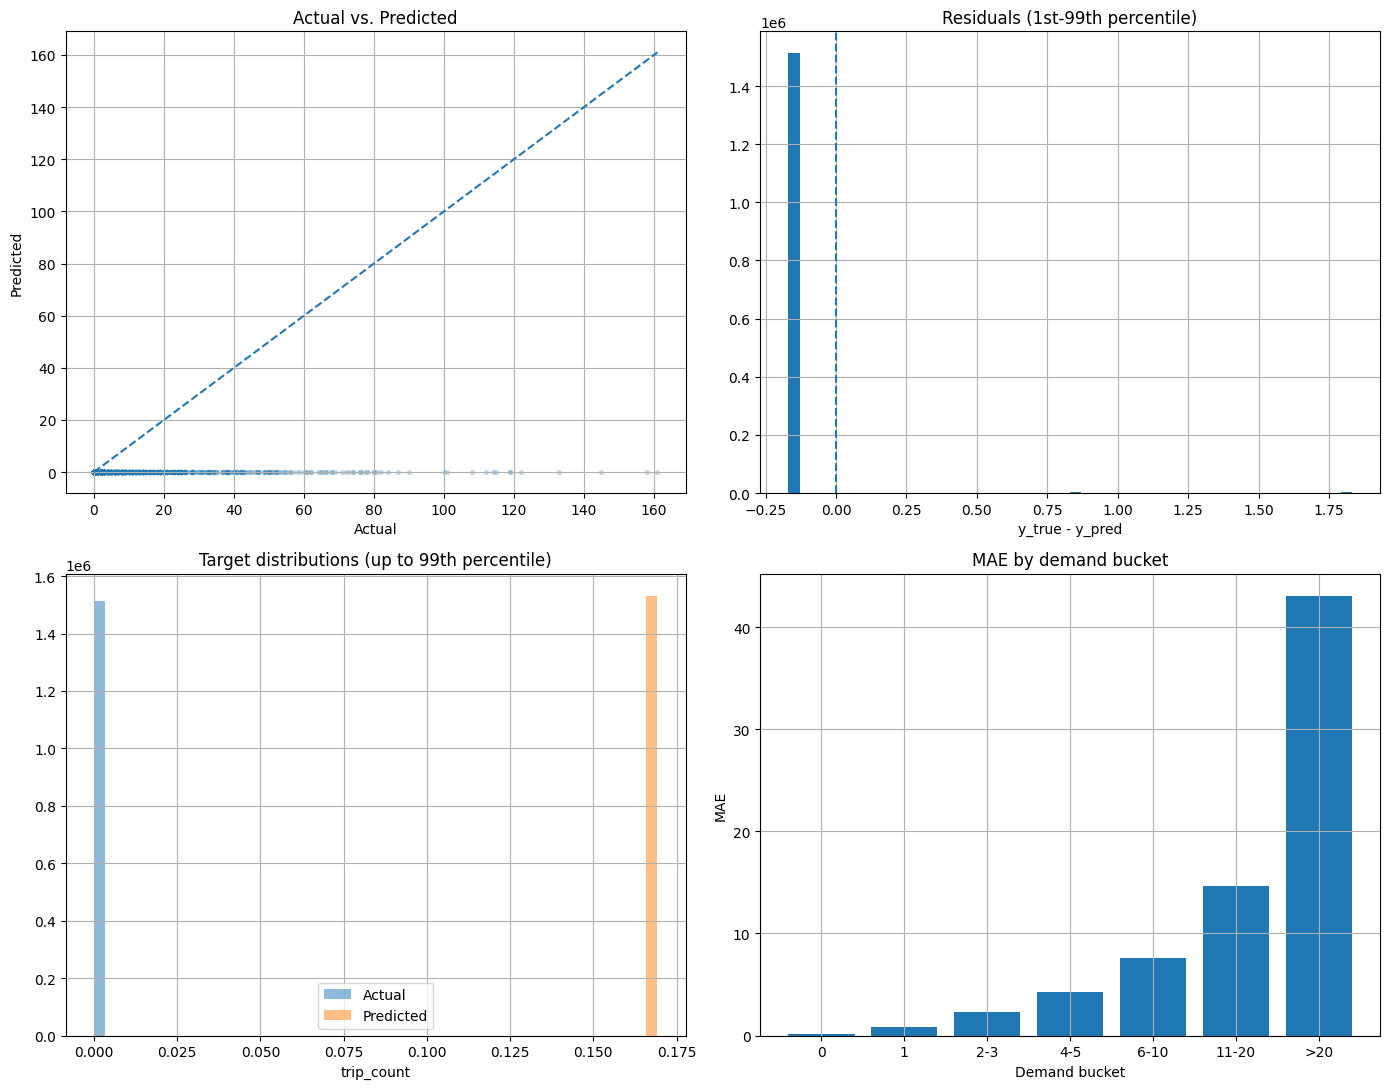

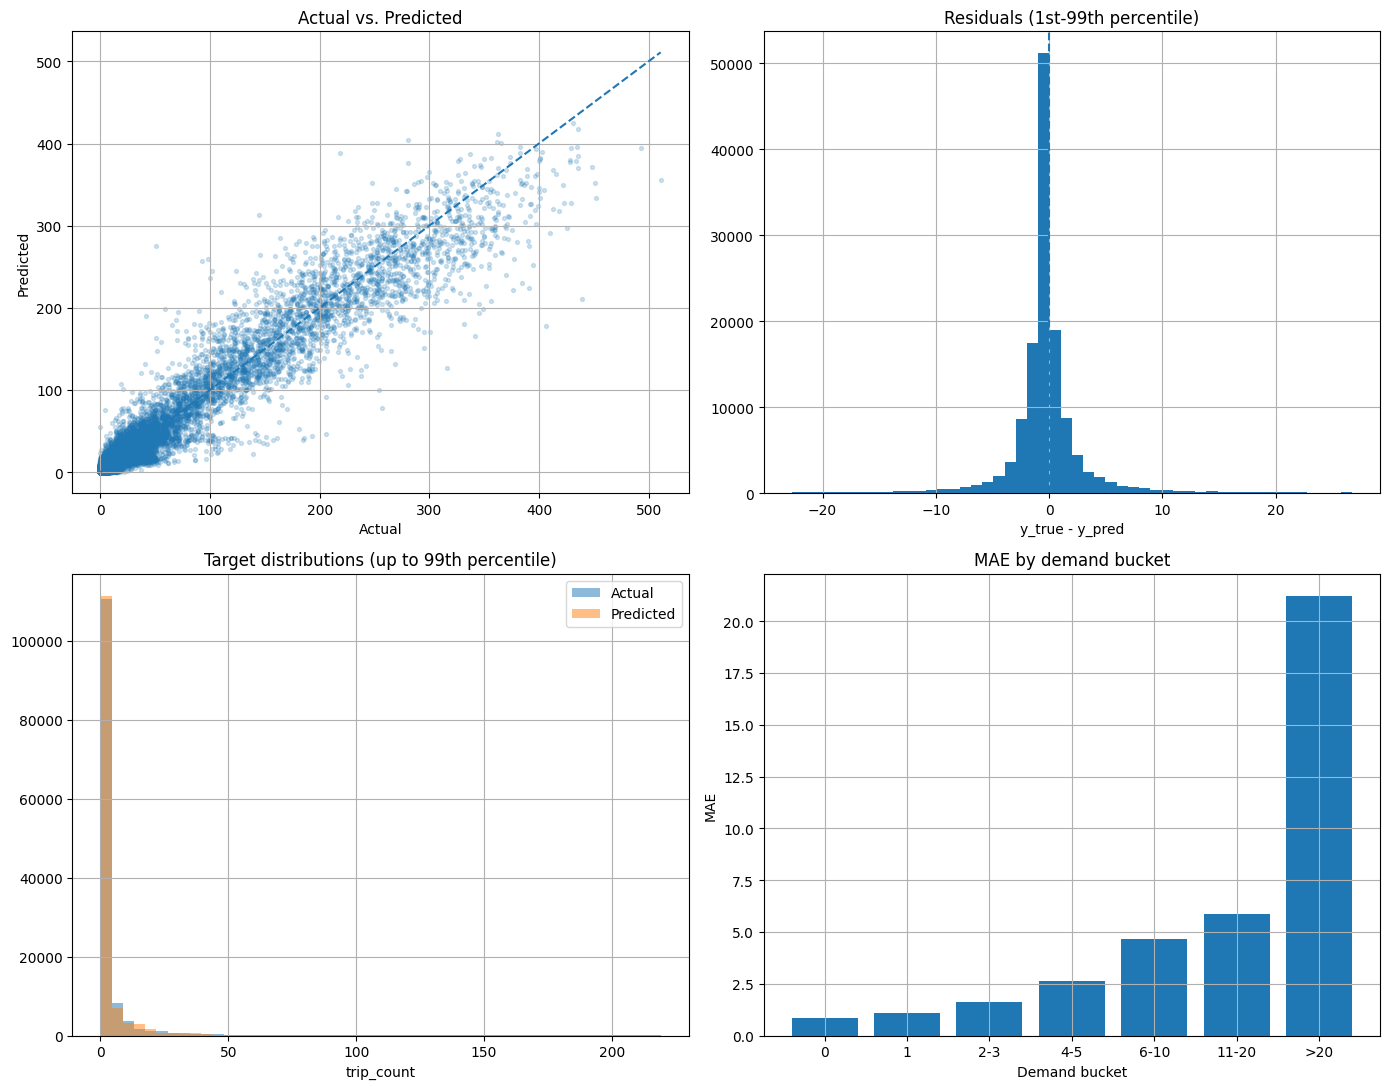

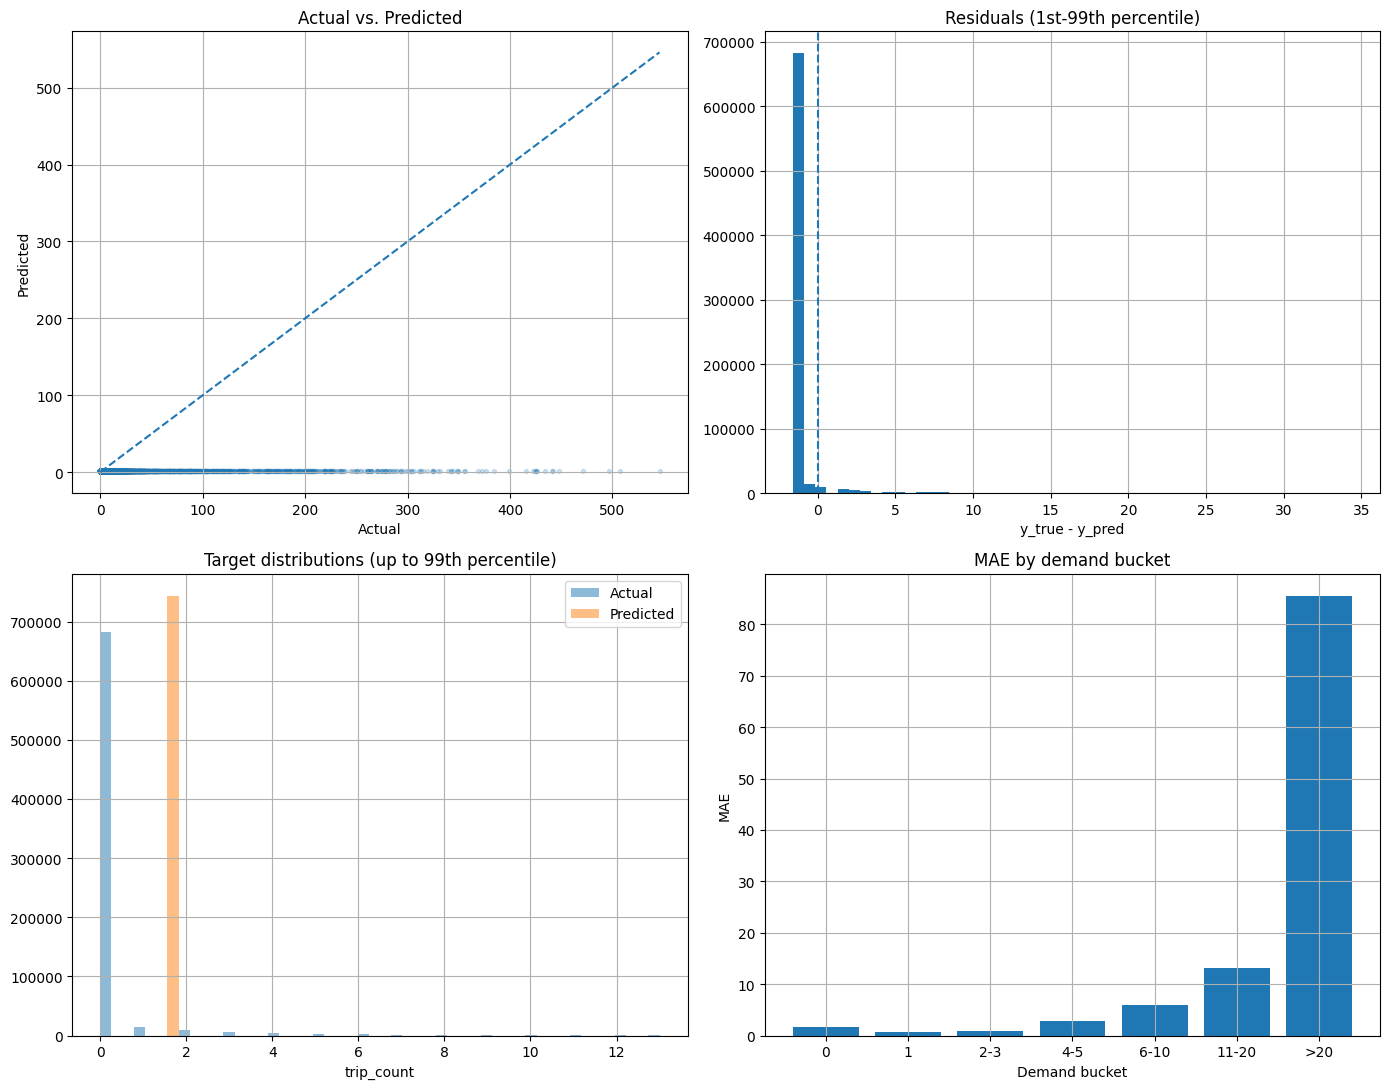

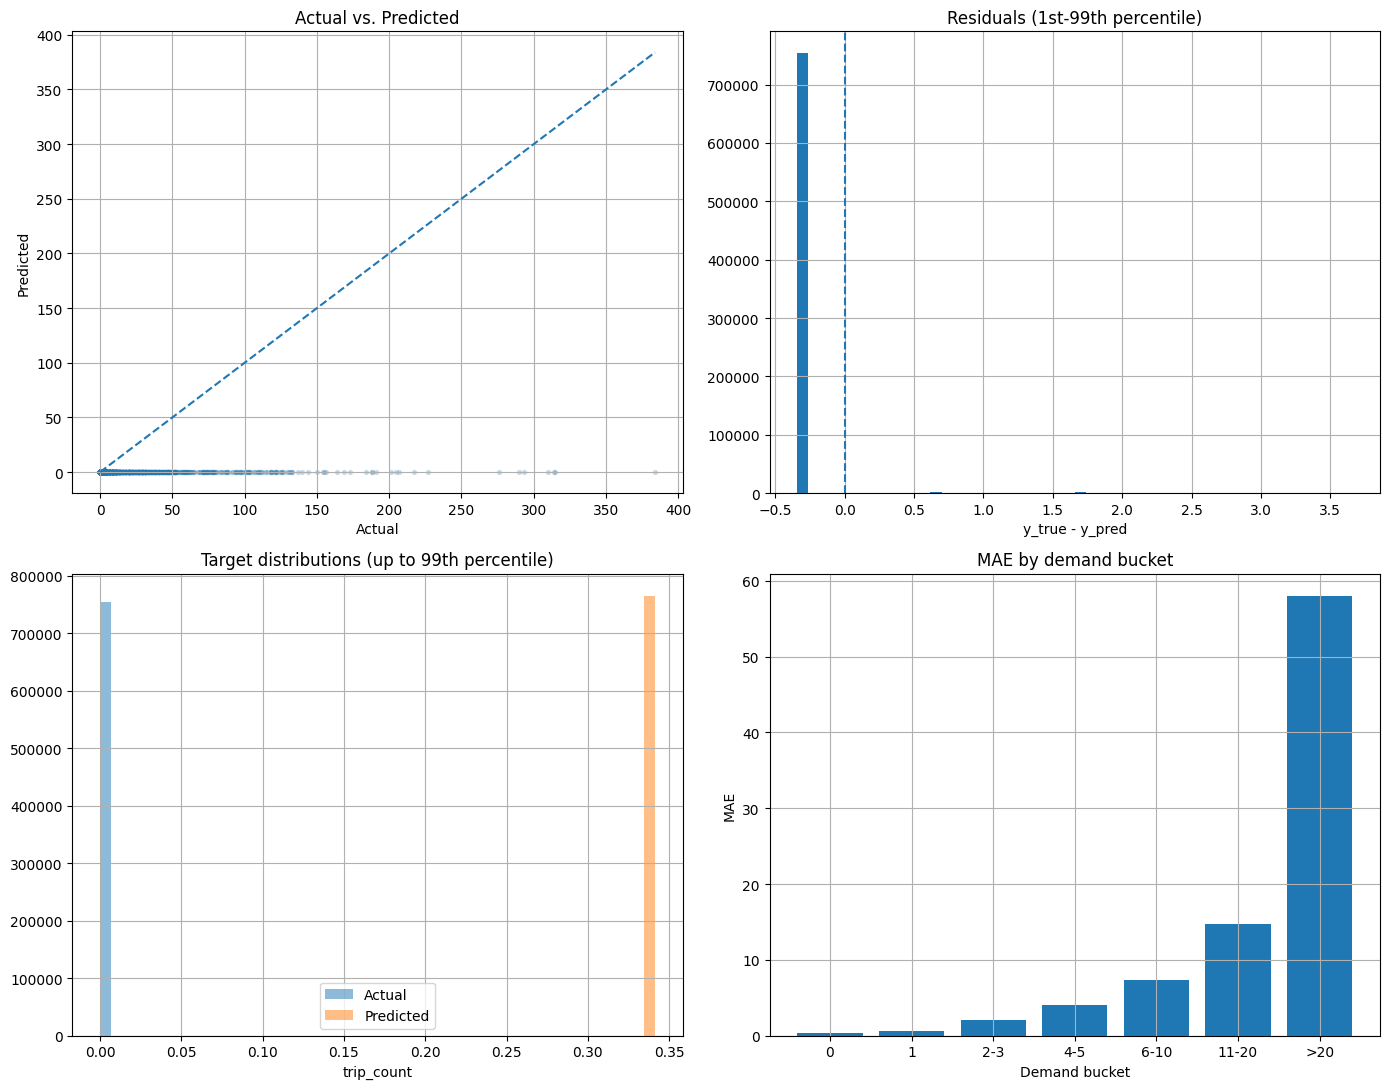

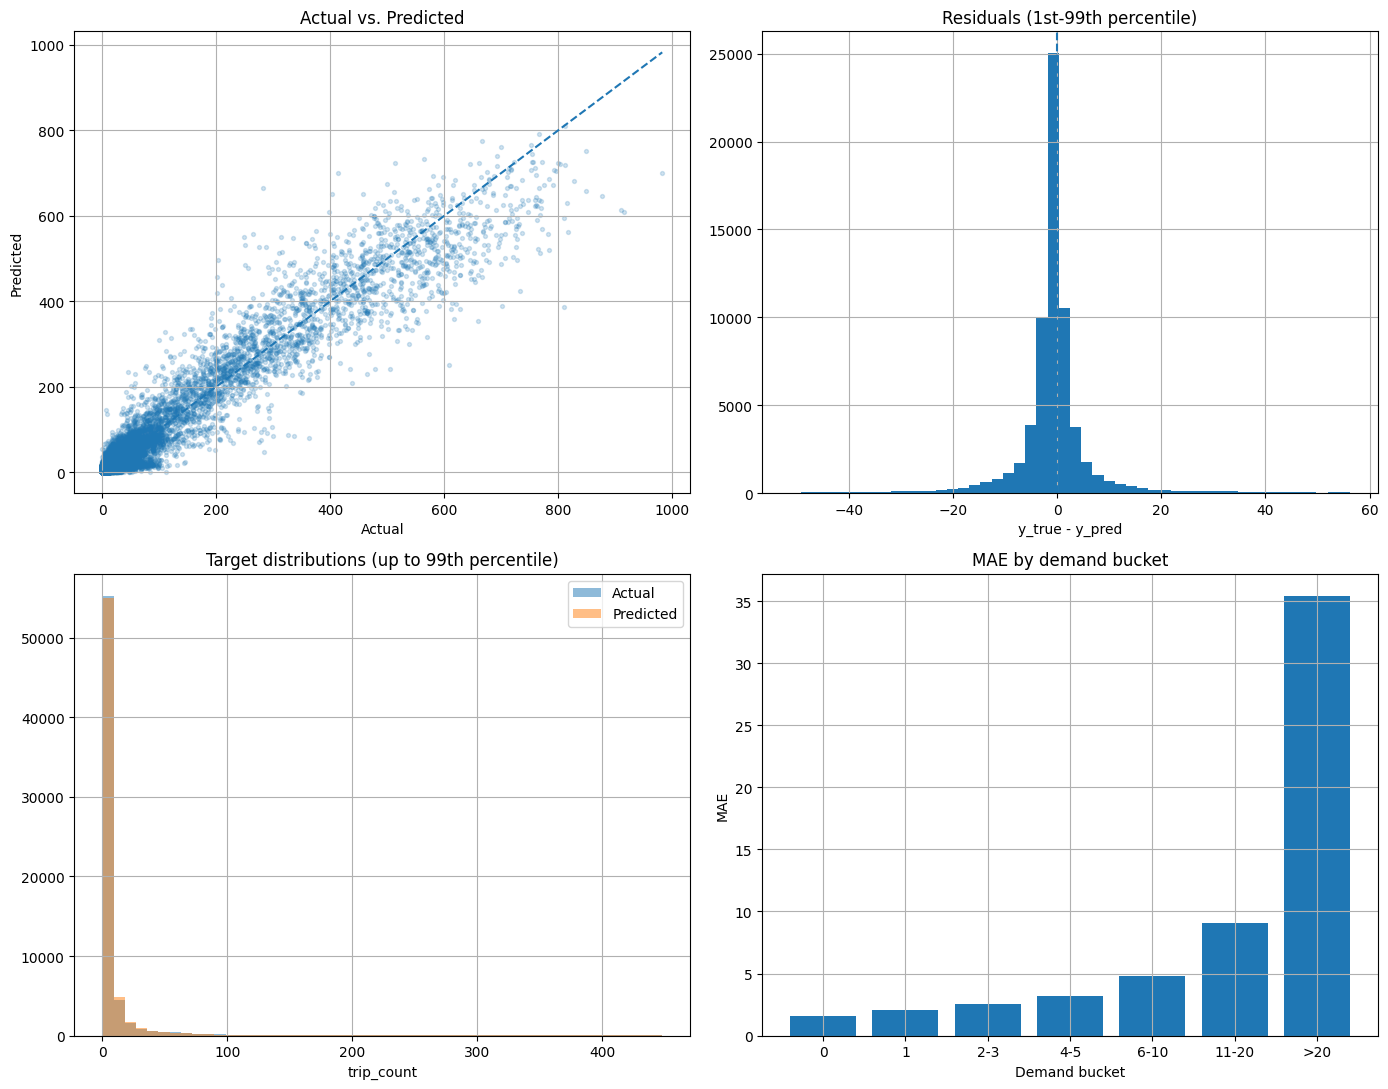

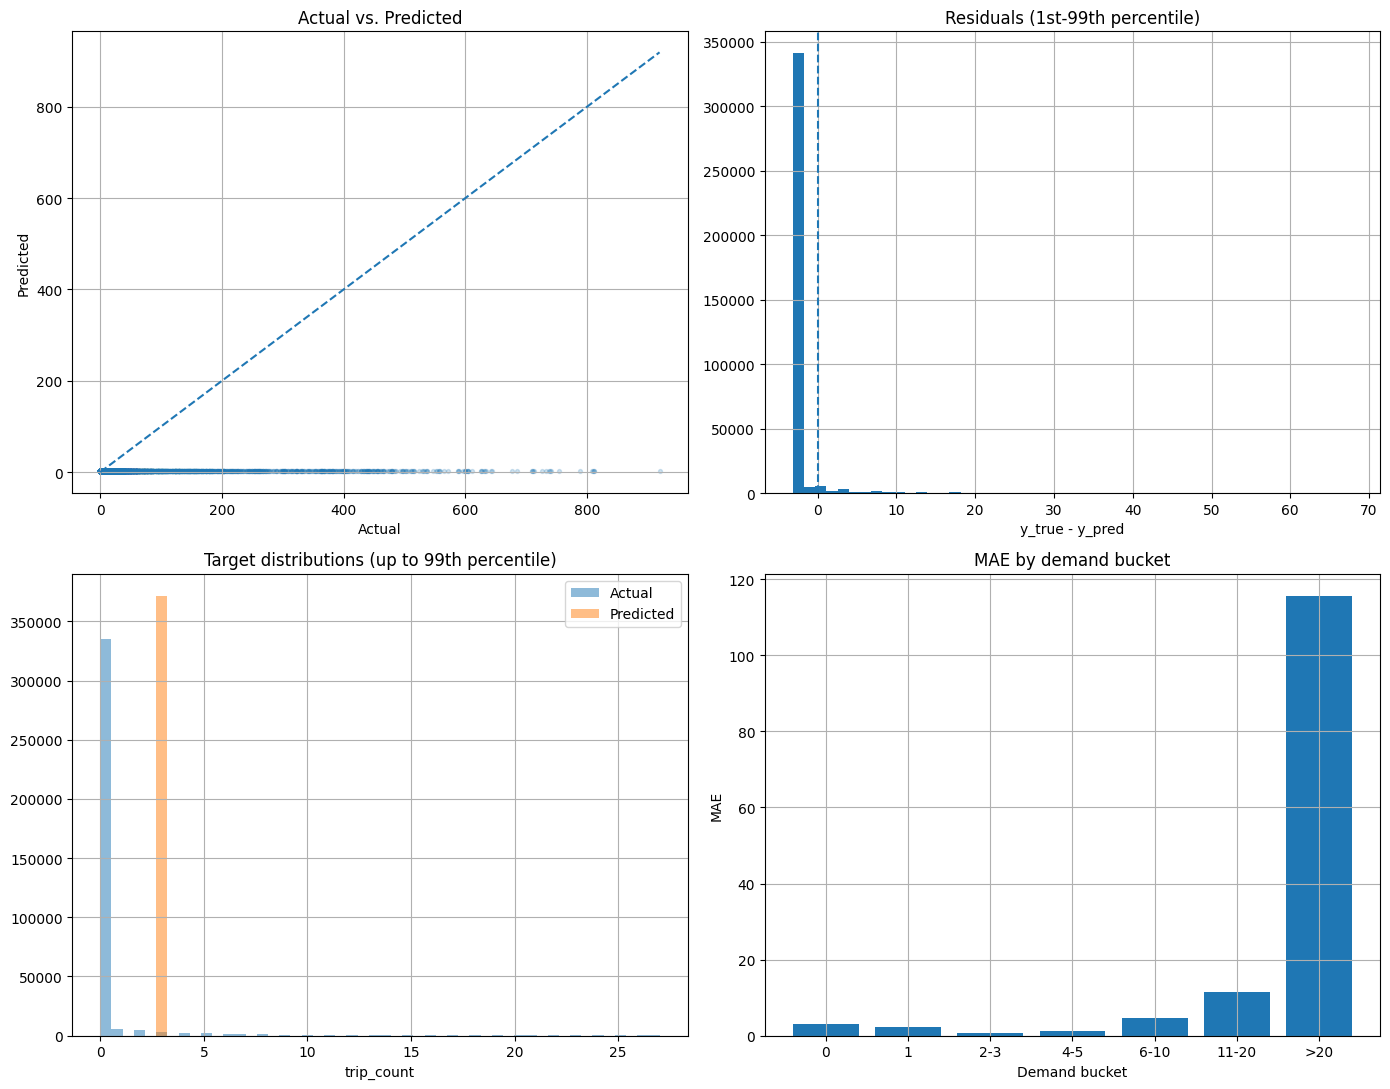

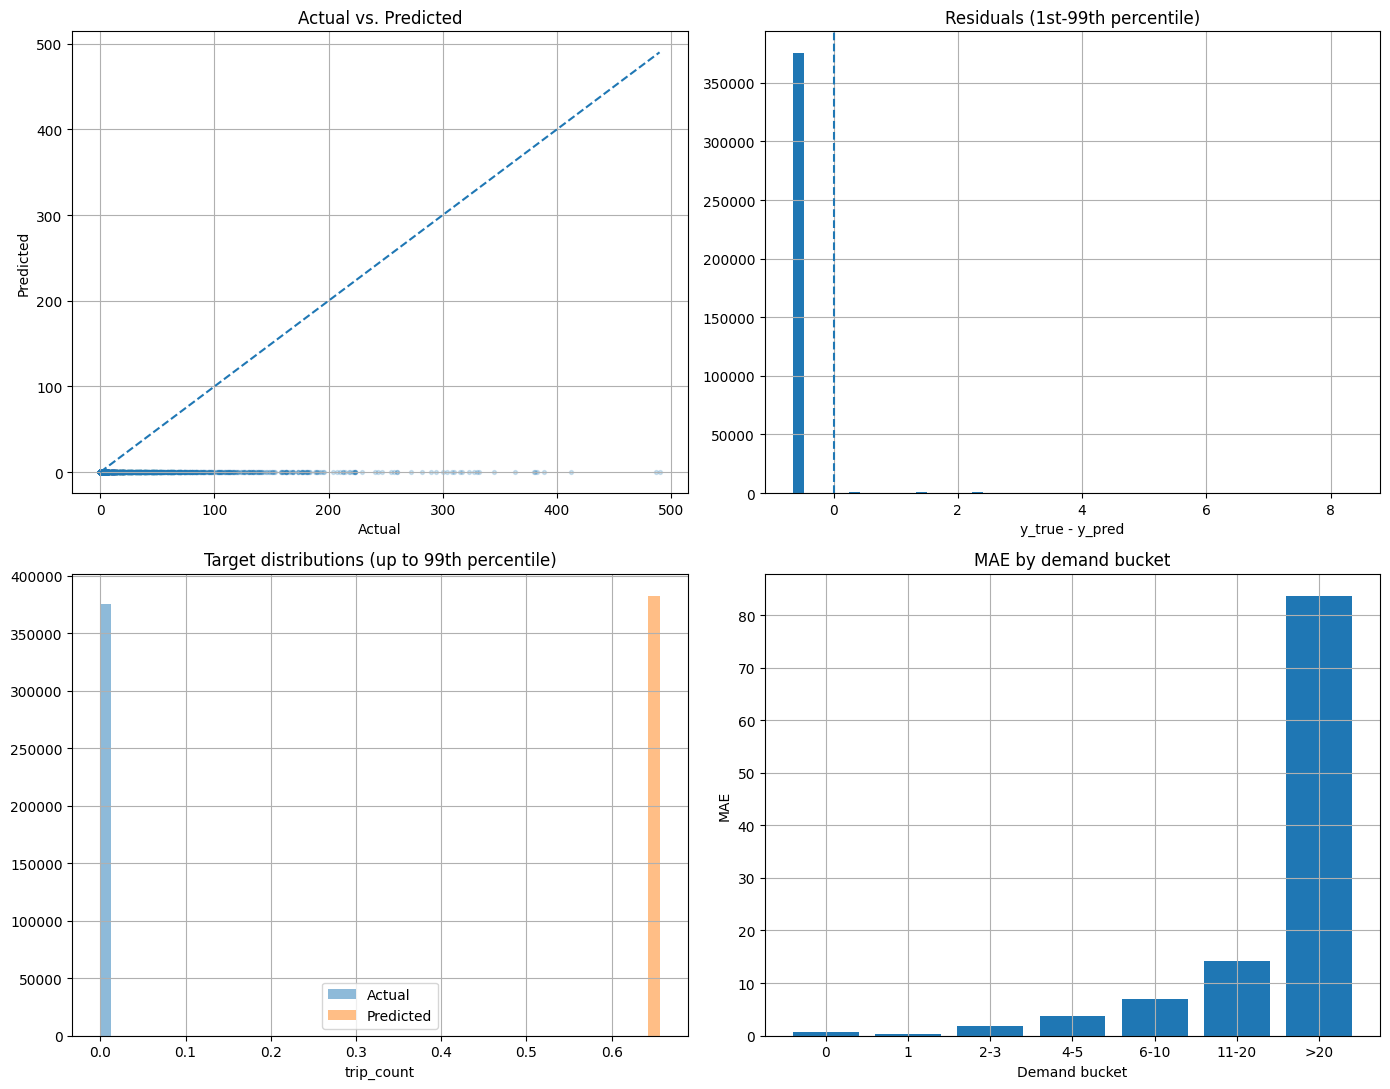

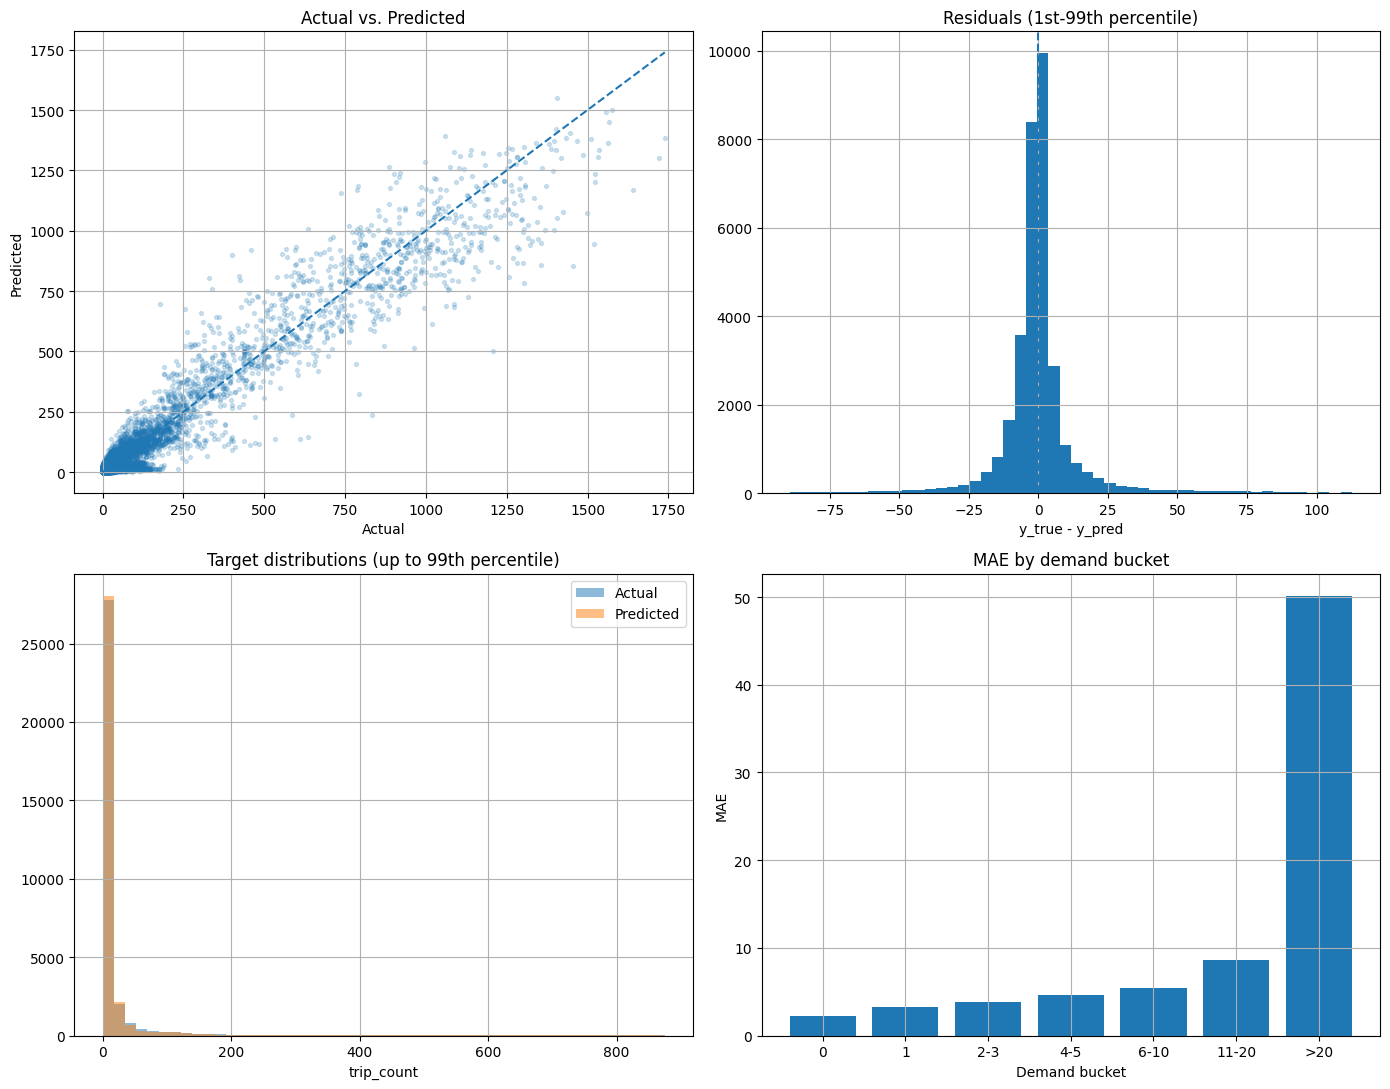

In [8]:
training_results = {}
history_dfs = {}

for dataset_config in DATASET_CONFIGS:
    result = train_dataset_baseline(dataset_config)
    model_tag = result["model_tag"]
    training_results[model_tag] = result
    history_dfs[model_tag] = result["history_df"]

print("Completed baseline models:", list(training_results))



EVALUATION: hexagon_1h
Best training epoch: 2
shape: (4, 2)
┌──────────┬───────────┐
│ metric   ┆ value     │
│ ---      ┆ ---       │
│ str      ┆ f64       │
╞══════════╪═══════════╡
│ mae      ┆ 1.476992  │
│ rmse     ┆ 7.291153  │
│ r2       ┆ 1.7881e-7 │
│ peak_mae ┆ 73.636734 │
└──────────┴───────────┘


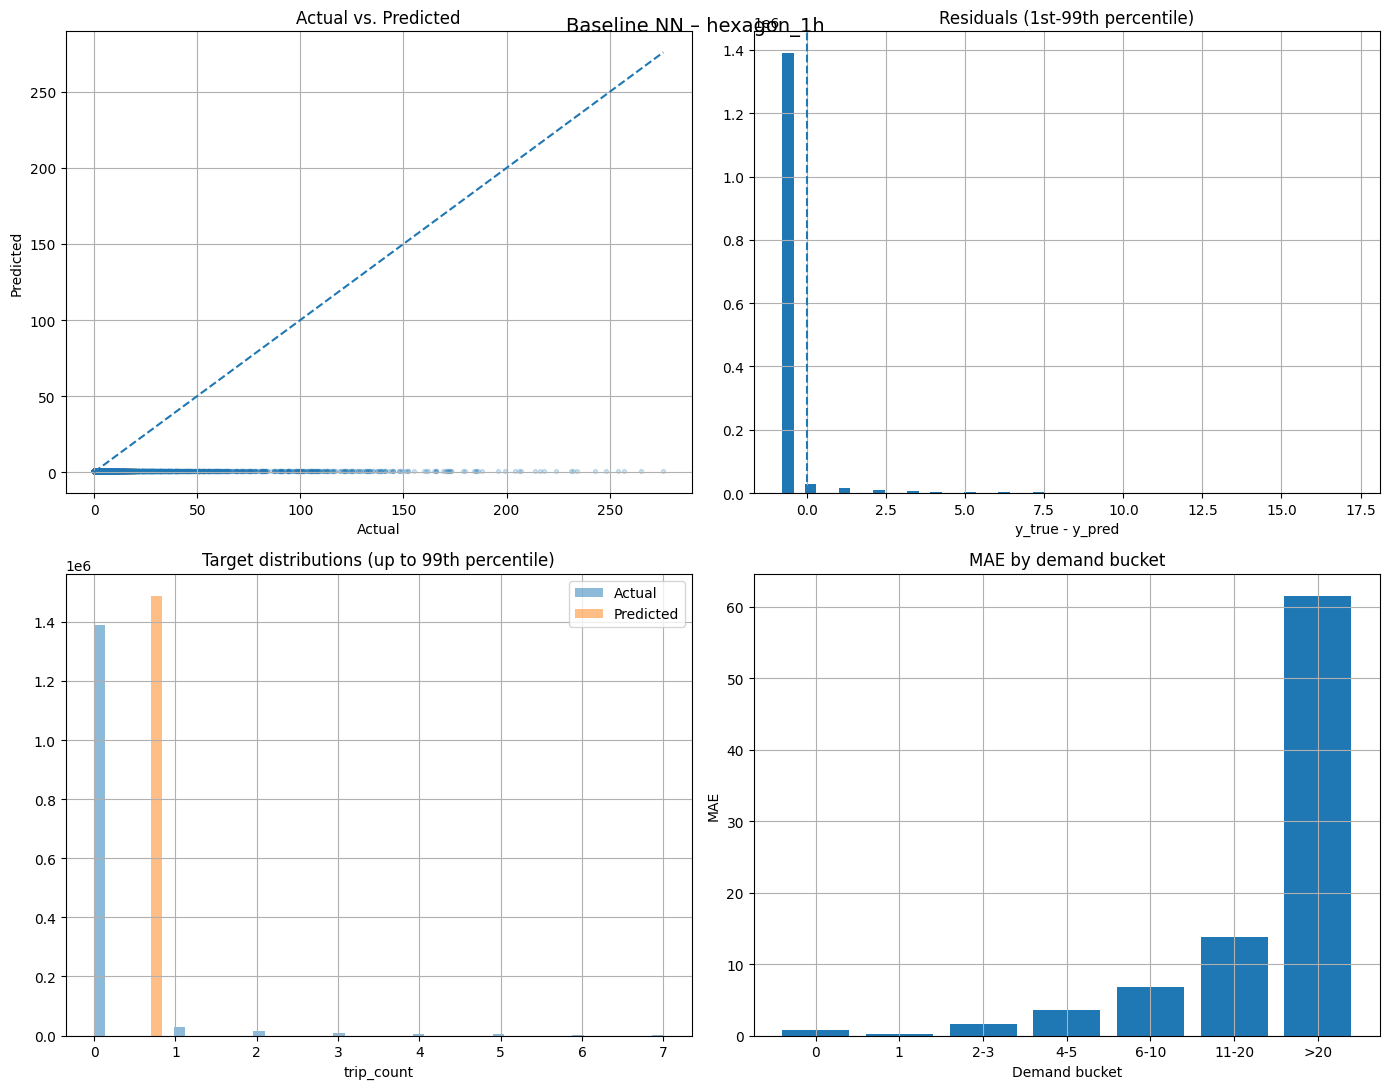

MAE by demand bucket:
shape: (7, 5)
┌───────────────┬─────────┬───────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows  ┆ mae       ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---     ┆ ---       ┆ ---        ┆ ---          │
│ str           ┆ u32     ┆ f32       ┆ f32        ┆ i64          │
╞═══════════════╪═════════╪═══════════╪════════════╪══════════════╡
│ 0             ┆ 1389237 ┆ 0.790842  ┆ 0.0        ┆ 0            │
│ 1             ┆ 29494   ┆ 0.209158  ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 25952   ┆ 1.581384  ┆ 2.372226   ┆ 2            │
│ 4-5           ┆ 10165   ┆ 3.619979  ┆ 4.410821   ┆ 3            │
│ 6-10          ┆ 11116   ┆ 6.843739  ┆ 7.634581   ┆ 4            │
│ 11-20         ┆ 8526    ┆ 13.82762  ┆ 14.618462  ┆ 5            │
│ >20           ┆ 13336   ┆ 61.552513 ┆ 62.343357  ┆ 6            │
└───────────────┴─────────┴───────────┴────────────┴──────────────┘

EVALUATION: census_tracts_1h
Best training epoch: 19
shape: (4, 2)
┌──────────┬

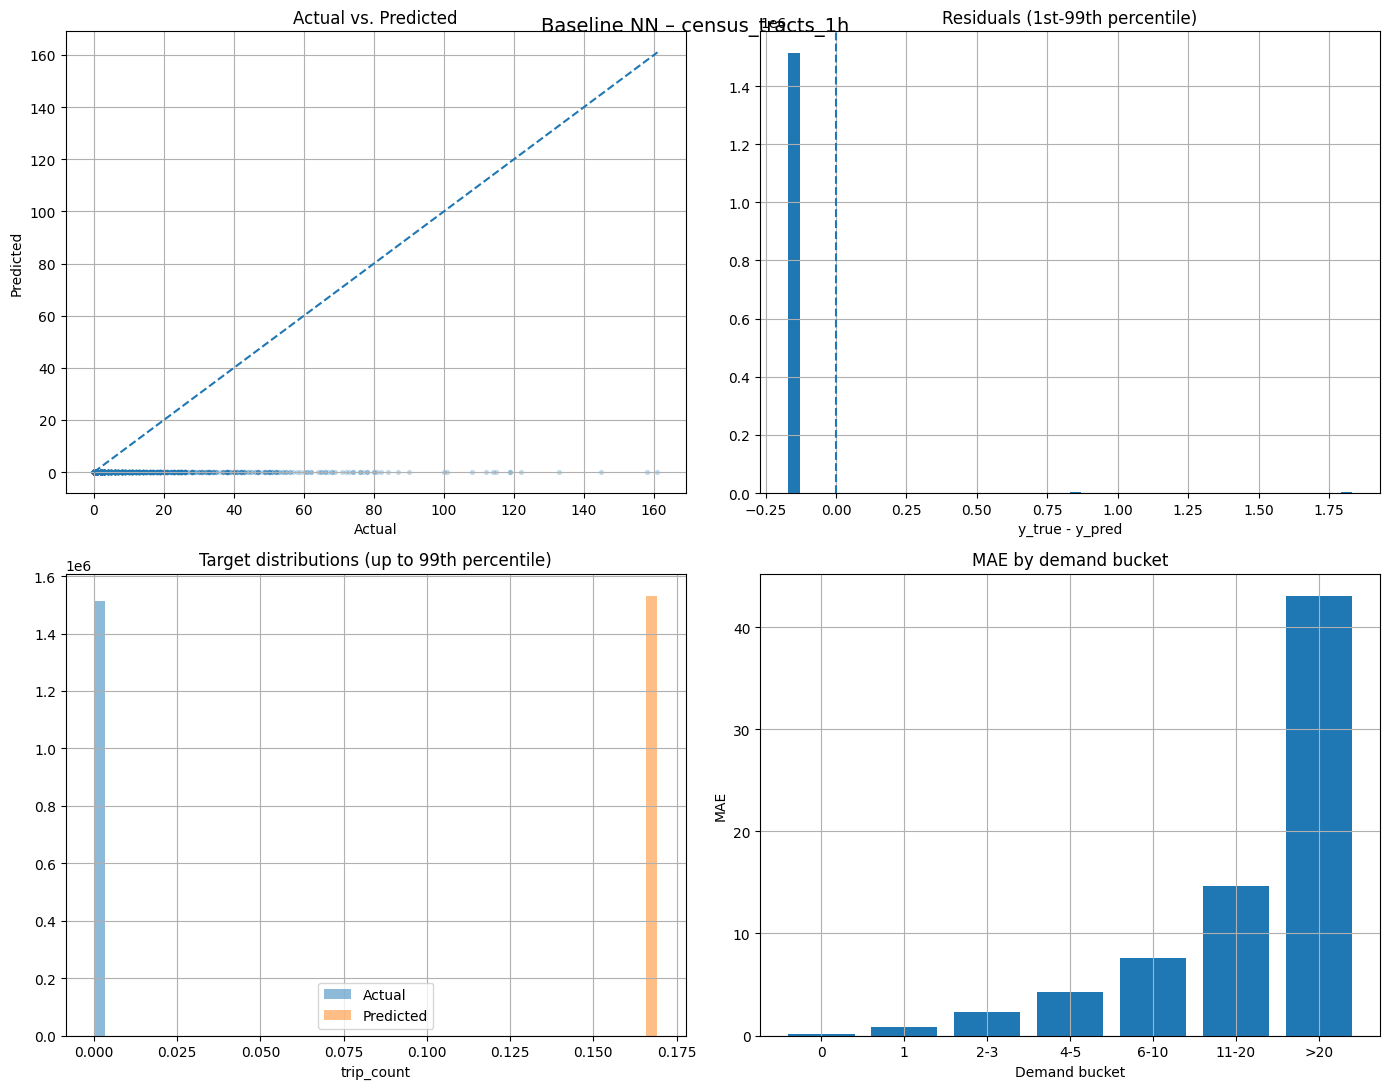

MAE by demand bucket:
shape: (7, 5)
┌───────────────┬─────────┬───────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows  ┆ mae       ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---     ┆ ---       ┆ ---        ┆ ---          │
│ str           ┆ u32     ┆ f32       ┆ f32        ┆ i64          │
╞═══════════════╪═════════╪═══════════╪════════════╪══════════════╡
│ 0             ┆ 1512540 ┆ 0.169263  ┆ 0.0        ┆ 0            │
│ 1             ┆ 2107    ┆ 0.830737  ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 4116    ┆ 2.267811  ┆ 2.437075   ┆ 2            │
│ 4-5           ┆ 2021    ┆ 4.308223  ┆ 4.477487   ┆ 3            │
│ 6-10          ┆ 3273    ┆ 7.627864  ┆ 7.797128   ┆ 4            │
│ 11-20         ┆ 3514    ┆ 14.648323 ┆ 14.817587  ┆ 5            │
│ >20           ┆ 3712    ┆ 43.064034 ┆ 43.233299  ┆ 6            │
└───────────────┴─────────┴───────────┴────────────┴──────────────┘

EVALUATION: community_areas_1h
Best training epoch: 95
shape: (4, 2)
┌─────────

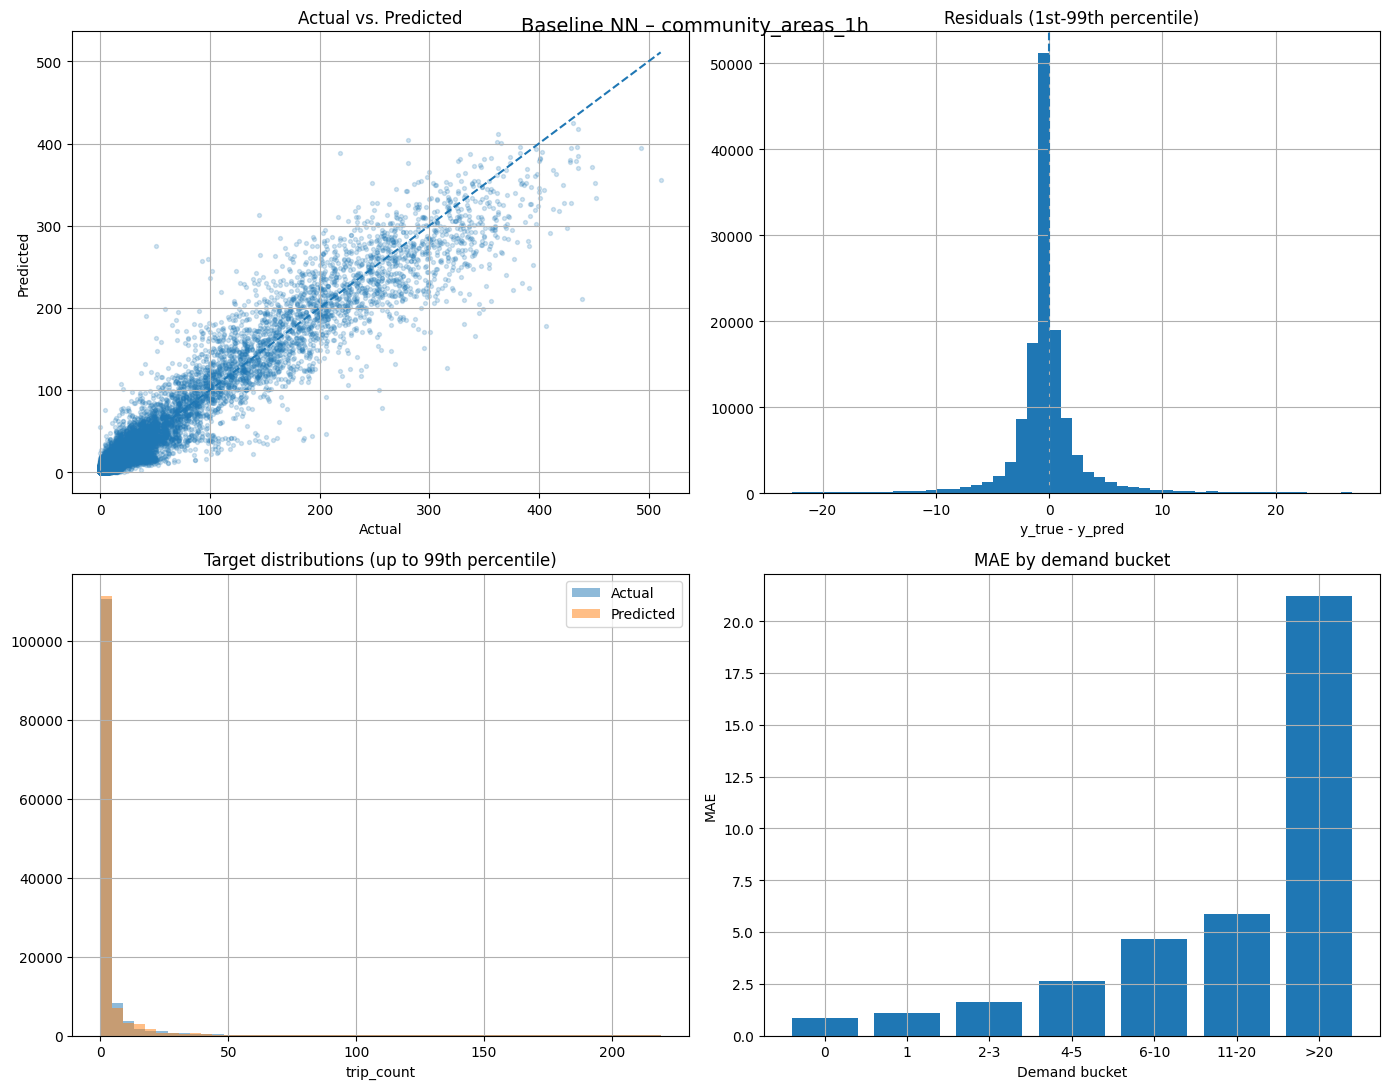

MAE by demand bucket:
shape: (7, 5)
┌───────────────┬────────┬───────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows ┆ mae       ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---    ┆ ---       ┆ ---        ┆ ---          │
│ str           ┆ u32    ┆ f32       ┆ f32        ┆ i64          │
╞═══════════════╪════════╪═══════════╪════════════╪══════════════╡
│ 0             ┆ 59291  ┆ 0.86878   ┆ 0.0        ┆ 0            │
│ 1             ┆ 25758  ┆ 1.113348  ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 20855  ┆ 1.601165  ┆ 2.362791   ┆ 2            │
│ 4-5           ┆ 7589   ┆ 2.651021  ┆ 4.395045   ┆ 3            │
│ 6-10          ┆ 7097   ┆ 4.646722  ┆ 7.511625   ┆ 4            │
│ 11-20         ┆ 4367   ┆ 5.859115  ┆ 14.680559  ┆ 5            │
│ >20           ┆ 9086   ┆ 21.220778 ┆ 105.667404 ┆ 6            │
└───────────────┴────────┴───────────┴────────────┴──────────────┘

EVALUATION: hexagon_2h
Best training epoch: 4
shape: (4, 2)
┌──────────┬────────────┐
│ metr

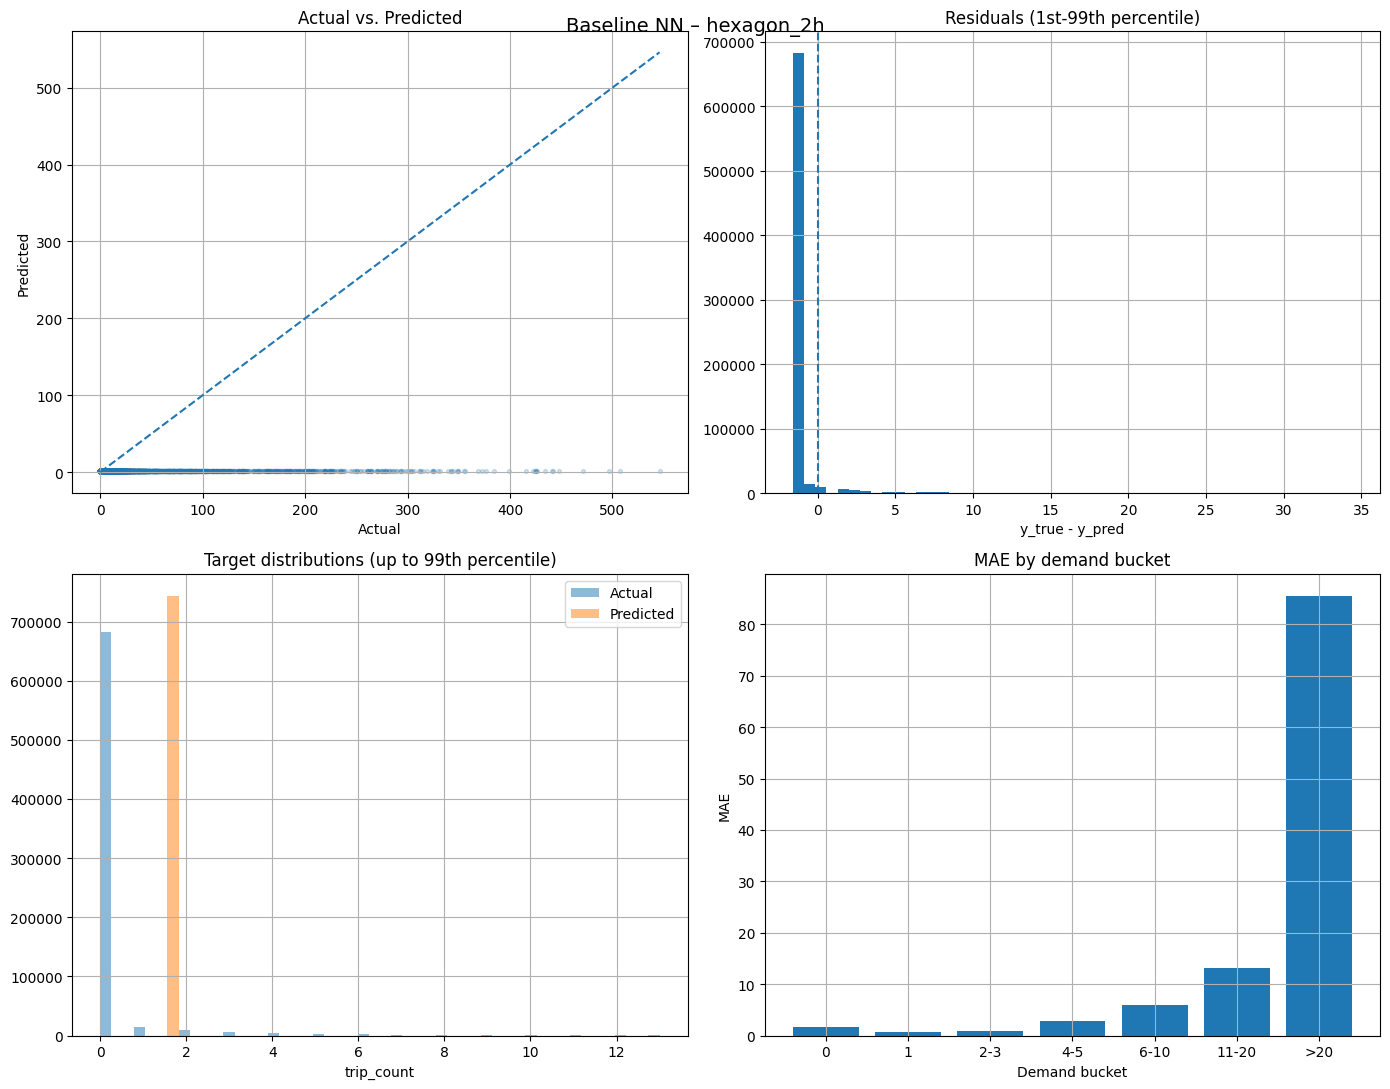

MAE by demand bucket:
shape: (7, 5)
┌───────────────┬────────┬───────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows ┆ mae       ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---    ┆ ---       ┆ ---        ┆ ---          │
│ str           ┆ u32    ┆ f32       ┆ f32        ┆ i64          │
╞═══════════════╪════════╪═══════════╪════════════╪══════════════╡
│ 0             ┆ 682233 ┆ 1.602382  ┆ 0.0        ┆ 0            │
│ 1             ┆ 13879  ┆ 0.602382  ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 15473  ┆ 0.796441  ┆ 2.398824   ┆ 2            │
│ 4-5           ┆ 7312   ┆ 2.815561  ┆ 4.417943   ┆ 3            │
│ 6-10          ┆ 7748   ┆ 5.967958  ┆ 7.570341   ┆ 4            │
│ 11-20         ┆ 5786   ┆ 13.164814 ┆ 14.767197  ┆ 5            │
│ >20           ┆ 11024  ┆ 85.529694 ┆ 87.132072  ┆ 6            │
└───────────────┴────────┴───────────┴────────────┴──────────────┘

EVALUATION: census_tracts_2h
Best training epoch: 15
shape: (4, 2)
┌──────────┬────────────┐

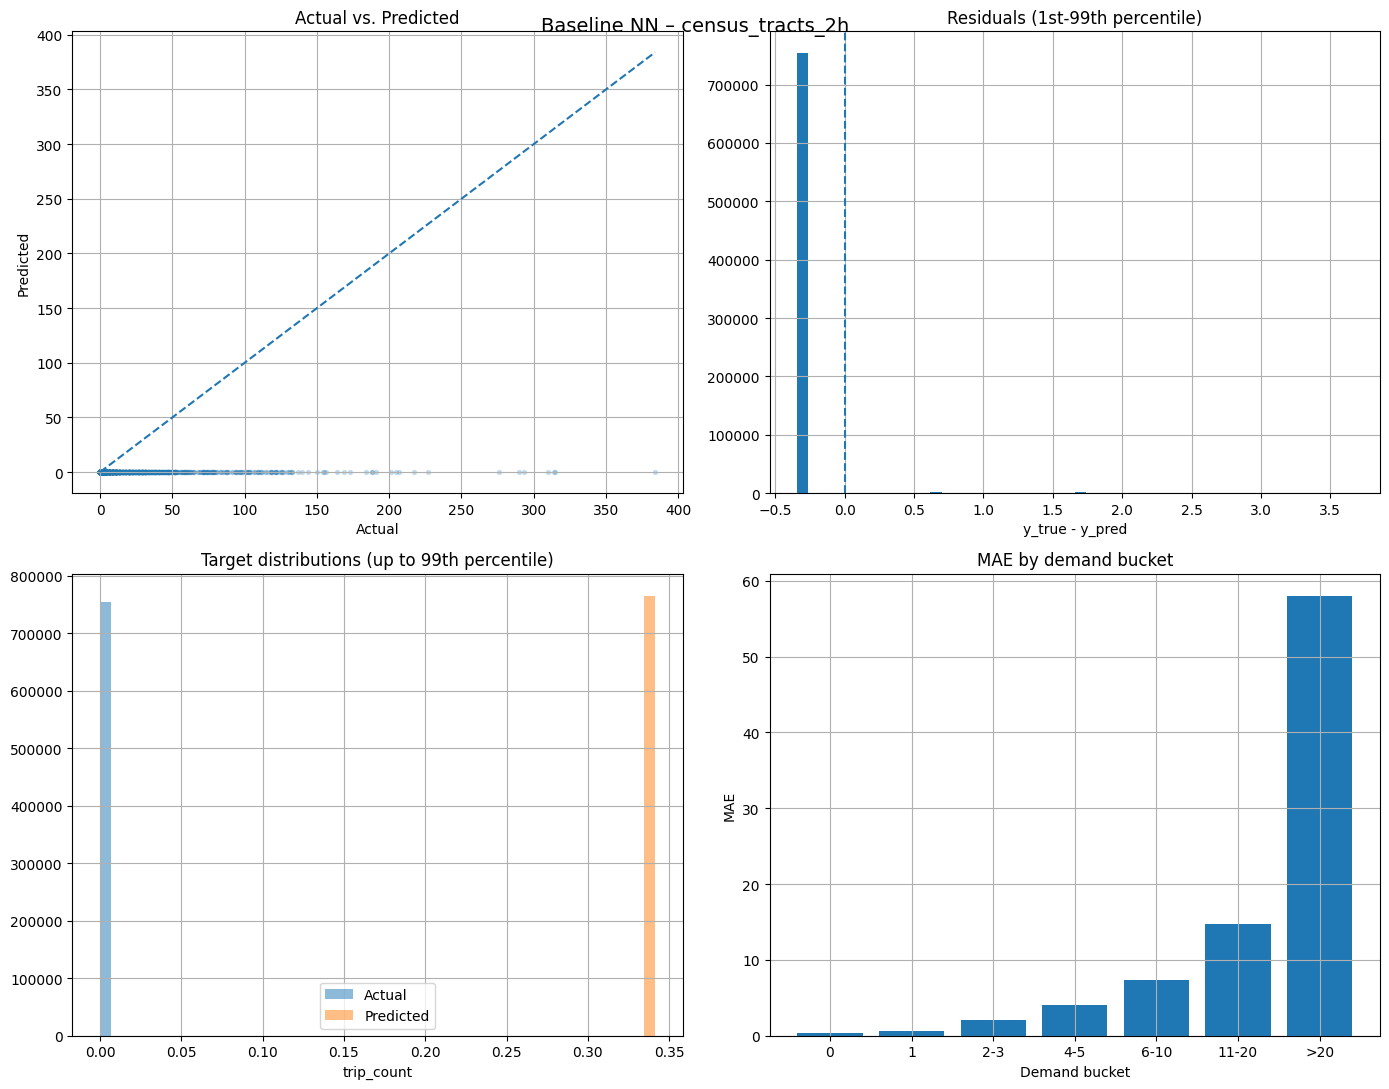

MAE by demand bucket:
shape: (7, 5)
┌───────────────┬────────┬───────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows ┆ mae       ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---    ┆ ---       ┆ ---        ┆ ---          │
│ str           ┆ u32    ┆ f32       ┆ f32        ┆ i64          │
╞═══════════════╪════════╪═══════════╪════════════╪══════════════╡
│ 0             ┆ 753604 ┆ 0.341359  ┆ 0.0        ┆ 0            │
│ 1             ┆ 1346   ┆ 0.658641  ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 2236   ┆ 2.082613  ┆ 2.423971   ┆ 2            │
│ 4-5           ┆ 1003   ┆ 4.101313  ┆ 4.442672   ┆ 3            │
│ 6-10          ┆ 1554   ┆ 7.380649  ┆ 7.722008   ┆ 4            │
│ 11-20         ┆ 1657   ┆ 14.689421 ┆ 15.030779  ┆ 5            │
│ >20           ┆ 3674   ┆ 58.037247 ┆ 58.378605  ┆ 6            │
└───────────────┴────────┴───────────┴────────────┴──────────────┘

EVALUATION: community_areas_2h
Best training epoch: 99
shape: (4, 2)
┌──────────┬───────────

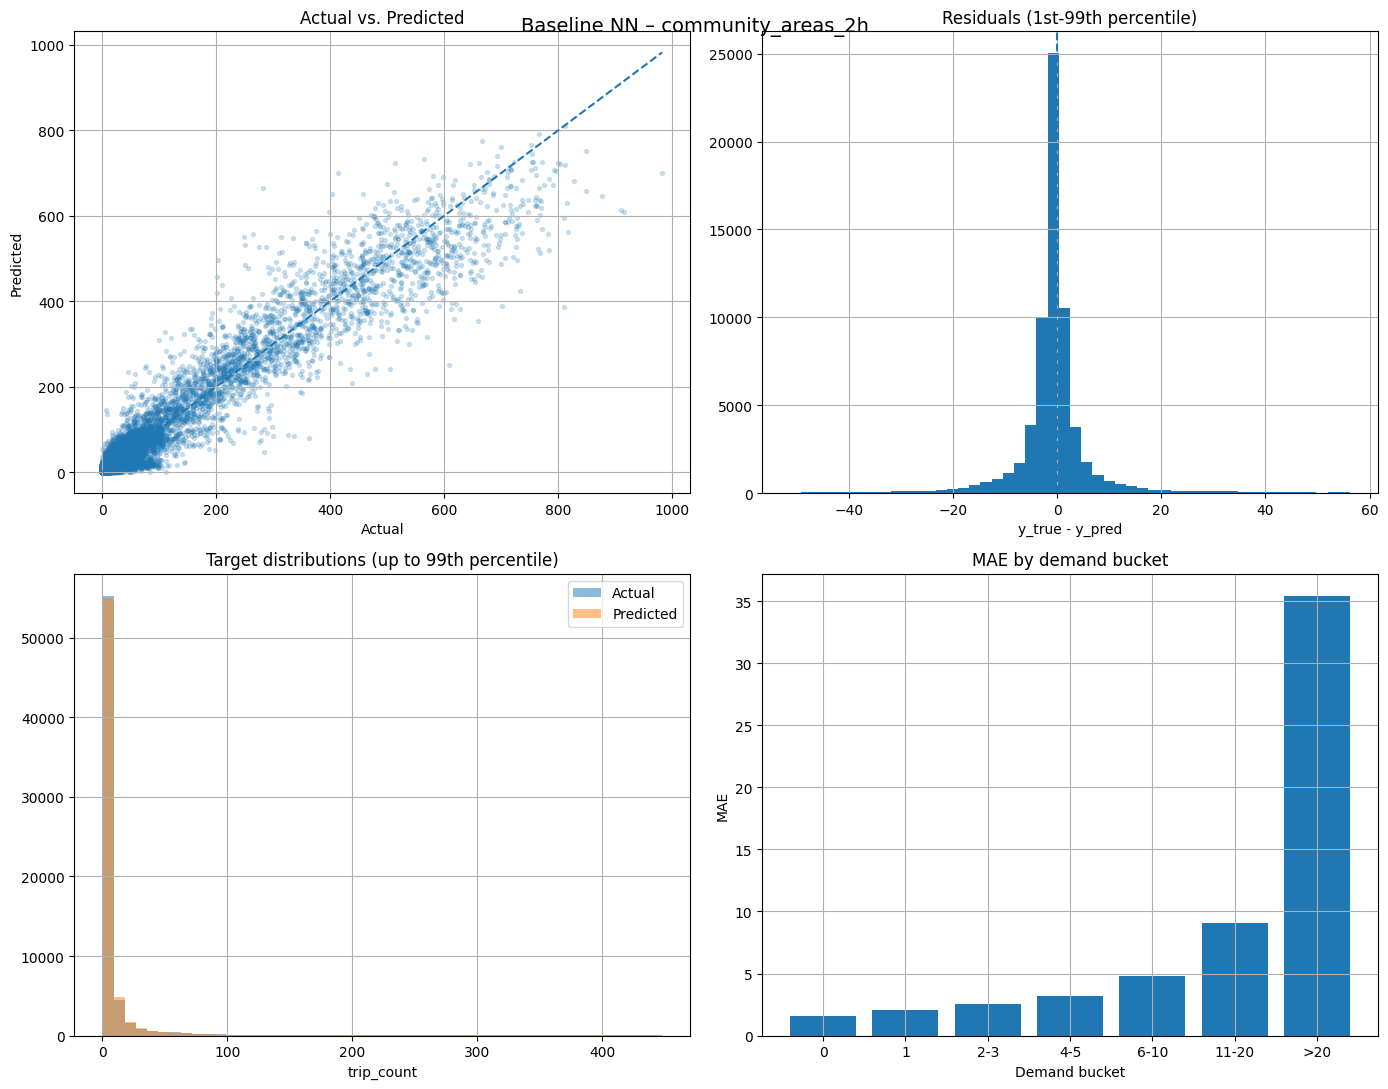

MAE by demand bucket:
shape: (7, 5)
┌───────────────┬────────┬───────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows ┆ mae       ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---    ┆ ---       ┆ ---        ┆ ---          │
│ str           ┆ u32    ┆ f32       ┆ f32        ┆ i64          │
╞═══════════════╪════════╪═══════════╪════════════╪══════════════╡
│ 0             ┆ 20753  ┆ 1.609637  ┆ 0.0        ┆ 0            │
│ 1             ┆ 11822  ┆ 2.086825  ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 12291  ┆ 2.516366  ┆ 2.405174   ┆ 2            │
│ 4-5           ┆ 6029   ┆ 3.172771  ┆ 4.425112   ┆ 3            │
│ 6-10          ┆ 5921   ┆ 4.789812  ┆ 7.513427   ┆ 4            │
│ 11-20         ┆ 3656   ┆ 9.106975  ┆ 14.547046  ┆ 5            │
│ >20           ┆ 6708   ┆ 35.420856 ┆ 156.311264 ┆ 6            │
└───────────────┴────────┴───────────┴────────────┴──────────────┘

EVALUATION: hexagon_4h
Best training epoch: 10
shape: (4, 2)
┌──────────┬────────────┐
│ met

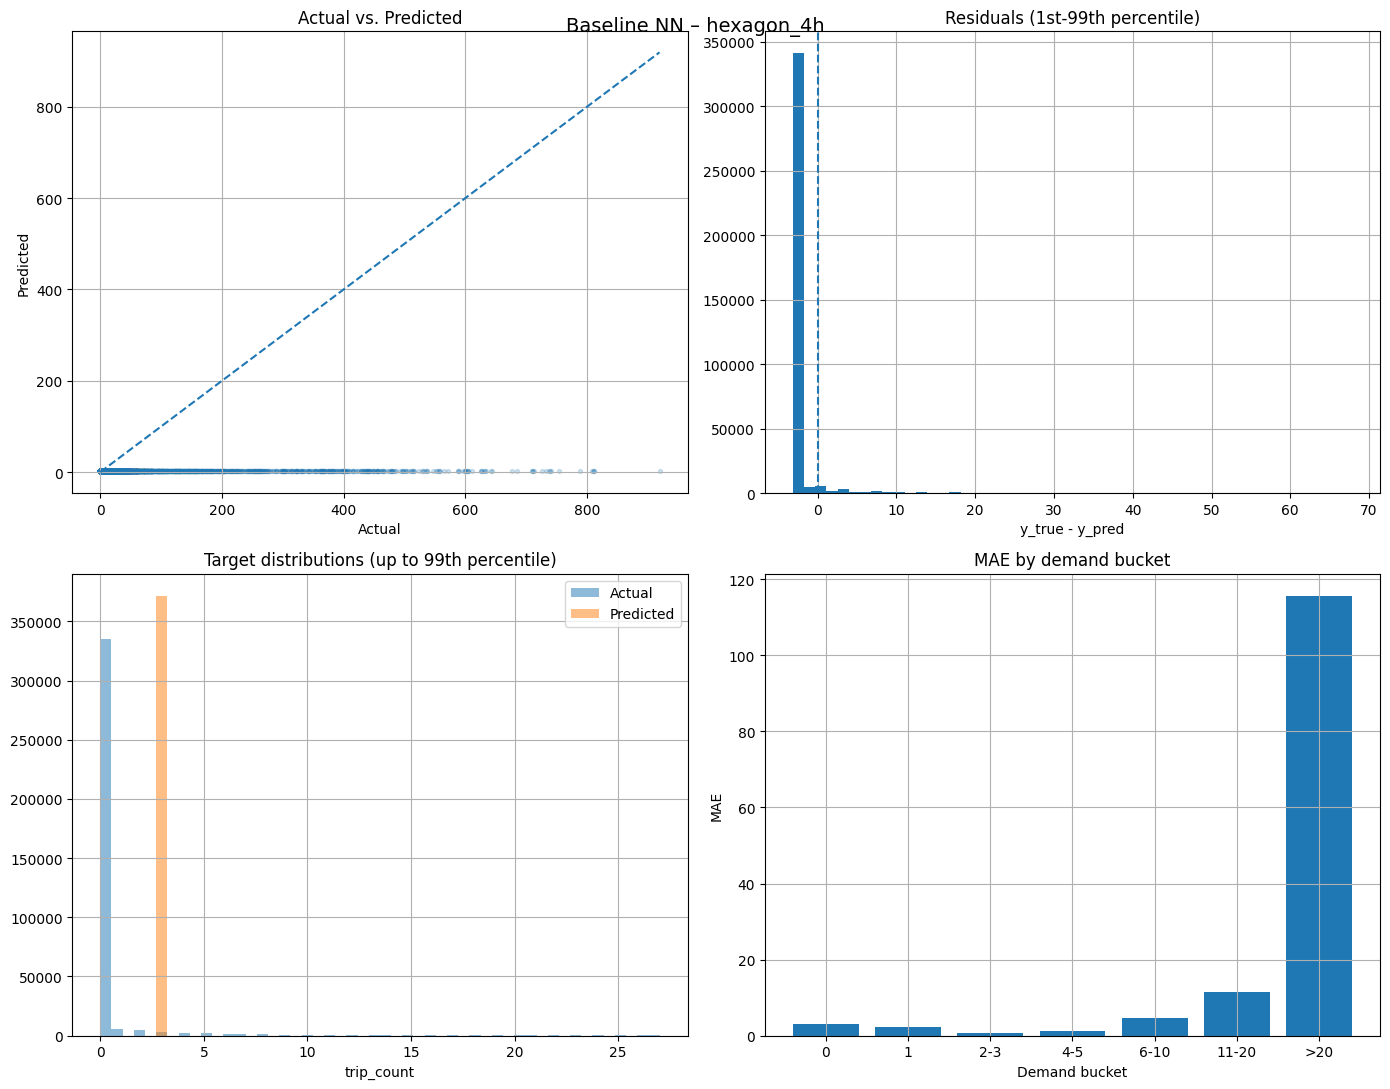

MAE by demand bucket:
shape: (7, 5)
┌───────────────┬────────┬────────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows ┆ mae        ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---    ┆ ---        ┆ ---        ┆ ---          │
│ str           ┆ u32    ┆ f32        ┆ f32        ┆ i64          │
╞═══════════════╪════════╪════════════╪════════════╪══════════════╡
│ 0             ┆ 335210 ┆ 3.157405   ┆ 0.0        ┆ 0            │
│ 1             ┆ 5881   ┆ 2.157405   ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 7797   ┆ 0.727752   ┆ 2.429652   ┆ 2            │
│ 4-5           ┆ 4408   ┆ 1.292459   ┆ 4.449864   ┆ 3            │
│ 6-10          ┆ 5677   ┆ 4.503508   ┆ 7.660913   ┆ 4            │
│ 11-20         ┆ 4061   ┆ 11.396153  ┆ 14.553558  ┆ 5            │
│ >20           ┆ 8649   ┆ 115.671013 ┆ 118.828423 ┆ 6            │
└───────────────┴────────┴────────────┴────────────┴──────────────┘

EVALUATION: census_tracts_4h
Best training epoch: 20
shape: (4, 2)
┌──────────┬

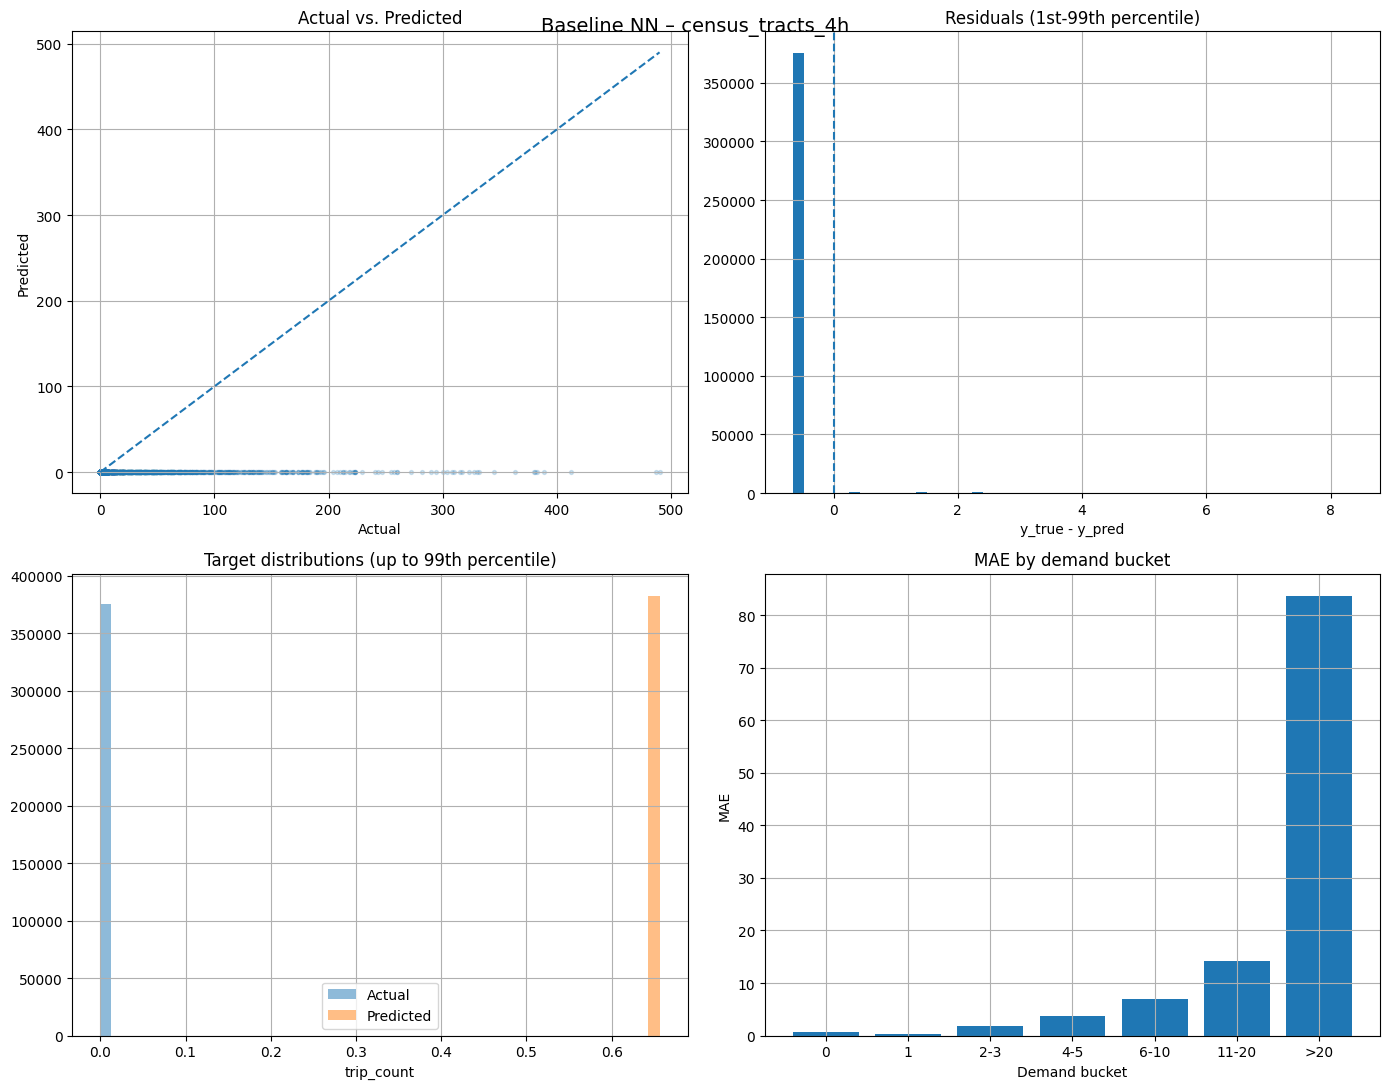

MAE by demand bucket:
shape: (7, 5)
┌───────────────┬────────┬───────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows ┆ mae       ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---    ┆ ---       ┆ ---        ┆ ---          │
│ str           ┆ u32    ┆ f32       ┆ f32        ┆ i64          │
╞═══════════════╪════════╪═══════════╪════════════╪══════════════╡
│ 0             ┆ 375204 ┆ 0.656151  ┆ 0.0        ┆ 0            │
│ 1             ┆ 924    ┆ 0.343849  ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 1404   ┆ 1.763365  ┆ 2.419516   ┆ 2            │
│ 4-5           ┆ 607    ┆ 3.790307  ┆ 4.446458   ┆ 3            │
│ 6-10          ┆ 895    ┆ 7.046642  ┆ 7.702793   ┆ 4            │
│ 11-20         ┆ 892    ┆ 14.246316 ┆ 14.902467  ┆ 5            │
│ >20           ┆ 2653   ┆ 83.655952 ┆ 84.312103  ┆ 6            │
└───────────────┴────────┴───────────┴────────────┴──────────────┘

EVALUATION: community_areas_4h
Best training epoch: 100
shape: (4, 2)
┌──────────┬──────────

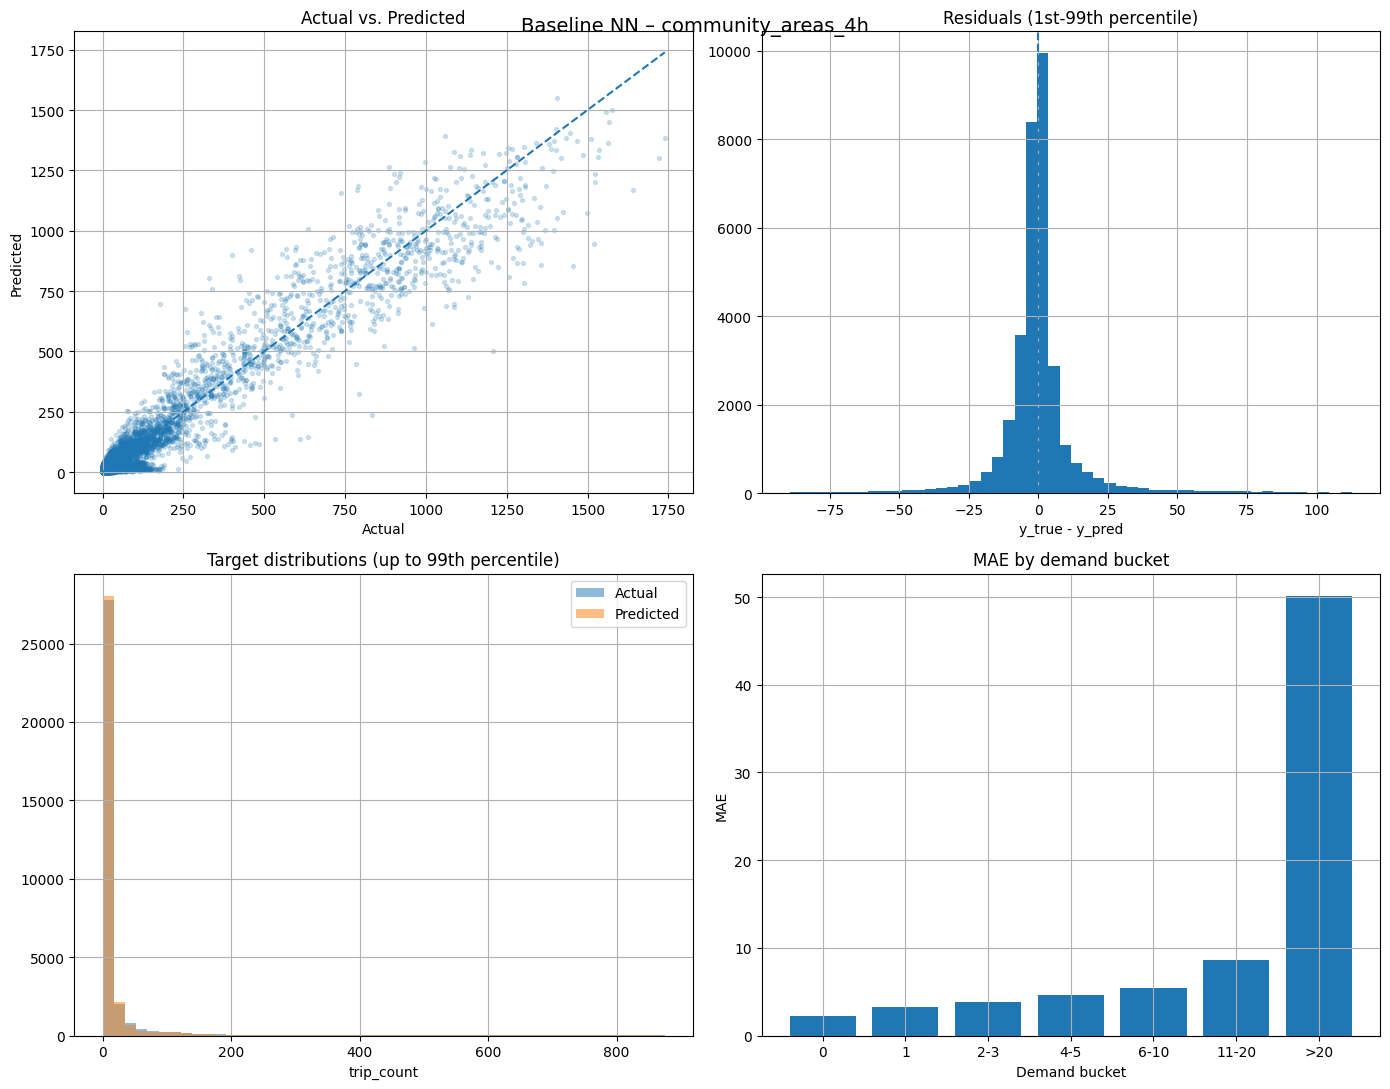

MAE by demand bucket:
shape: (7, 5)
┌───────────────┬────────┬───────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows ┆ mae       ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---    ┆ ---       ┆ ---        ┆ ---          │
│ str           ┆ u32    ┆ f32       ┆ f32        ┆ i64          │
╞═══════════════╪════════╪═══════════╪════════════╪══════════════╡
│ 0             ┆ 6632   ┆ 2.281495  ┆ 0.0        ┆ 0            │
│ 1             ┆ 4650   ┆ 3.225551  ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 5874   ┆ 3.869846  ┆ 2.434116   ┆ 2            │
│ 4-5           ┆ 3559   ┆ 4.609773  ┆ 4.443945   ┆ 3            │
│ 6-10          ┆ 4548   ┆ 5.451528  ┆ 7.604661   ┆ 4            │
│ 11-20         ┆ 3049   ┆ 8.590446  ┆ 14.407675  ┆ 5            │
│ >20           ┆ 5260   ┆ 50.143921 ┆ 203.011215 ┆ 6            │
└───────────────┴────────┴───────────┴────────────┴──────────────┘

Evaluated best models: ['hexagon_1h', 'census_tracts_1h', 'community_areas_1h', 'hexagon_2h'

In [10]:
# Reload every best model and reproduce its validation evaluation.
evaluation_results = {}

for dataset_config in DATASET_CONFIGS:
    spatial_unit = dataset_config['spatial_unit']
    spatial_col = dataset_config['spatial_col']
    time_unit = dataset_config['time_unit']
    model_tag = f"{spatial_unit}_{time_unit}"
    dataset_stem = f"GOLD_{time_unit.upper()}_DEMAND_{spatial_unit.upper()}"
    checkpoint_path = MODEL_PATH / f"baseline_NN_{model_tag}_best_model.pt"

    if not checkpoint_path.exists():
        print(f"\n[SKIPPED] {model_tag}: checkpoint not found at {checkpoint_path}")
        continue

    model, checkpoint = load_model_from_checkpoint(
        TaxiDemandNN, checkpoint_path, device=device
    )
    feature_cols = checkpoint['feature_cols']
    spatial_to_idx = checkpoint['spatial_to_idx']
    train_df = pl.read_parquet(
        PATHS.train_test_dir / f"{dataset_stem}_TRAIN.parquet"
    )
    val_df = pl.read_parquet(
        PATHS.train_test_dir / f"{dataset_stem}_VAL.parquet"
    )

    def prepare_features(frame):
        return frame.select(feature_cols).with_columns(
            pl.col(spatial_col).cast(pl.String)
            .replace_strict(spatial_to_idx, default=-1)
            .cast(pl.Float32).alias(spatial_col)
        )

    scaler = StandardScaler()
    scaler.fit(prepare_features(train_df).to_numpy())
    X_val_scaled = scaler.transform(
        prepare_features(val_df).to_numpy()
    ).astype('float32')
    y_val = val_df.select(TARGET_COL).to_numpy().astype('float32')
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val_scaled), torch.tensor(y_val)),
        batch_size=checkpoint['batch_size'],
        shuffle=False,
    )
    val_eval_df = collect_predictions(
        model, val_loader, device=device, embedding_input=False,
        inverse_target=lambda values: values,
    )
    metrics_df = compute_regression_metrics(val_eval_df)
    headline_metrics_df = metrics_df.filter(
        pl.col('metric').is_in(['mae', 'rmse', 'r2', 'peak_mae'])
    )

    print("\n" + "=" * 80)
    print(f"EVALUATION: {model_tag}")
    print(f"Best training epoch: {checkpoint['epoch']}")
    print(headline_metrics_df)
    figure, bucket_metrics_df = plot_regression_diagnostics(val_eval_df)
    figure.suptitle(f"Baseline NN – {model_tag}", fontsize=14)
    plt.show()
    print("MAE by demand bucket:")
    print(bucket_metrics_df)
    evaluation_results[model_tag] = {
        'metrics': metrics_df,
        'bucket_metrics': bucket_metrics_df,
        'predictions': val_eval_df,
    }

print("\nEvaluated best models:", list(evaluation_results))
